<a href="https://colab.research.google.com/github/ThakorYash/CarbonCheck-CO2-Emission-Analysis.-/blob/main/yash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CarbonCheck-CO2-Emission-Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Load CSV dataset
# FileNotFoundError: 'co2_emissions_kt_by_country.csv' not found.
# Please upload this file to your Colab environment, or update the file path.
df = pd.read_csv("co2_emissions_kt_by_country.csv")

# Show first rows
df.head()

,country_code,country_name,year,value
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


In [ ]:
# Remove missing values
df = df.dropna()

# Convert year to integer
df["year"] = df["year"].astype(int)

print("Dataset Shape:", df.shape)
print(df.info())


Dataset Shape: (13953, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13953 entries, 0 to 13952
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  13953 non-null  object 
 1   country_name  13953 non-null  object 
 2   year          13953 non-null  int64  
 3   value         13953 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 436.2+ KB
None


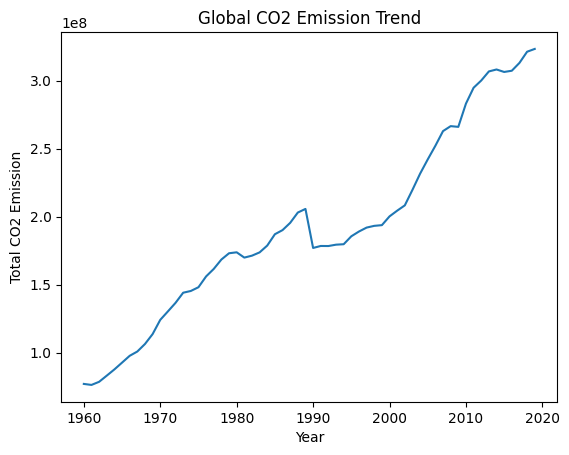

In [ ]:
global_trend = df.groupby("year")["value"].sum()

plt.figure()
plt.plot(global_trend.index, global_trend.values)
plt.title("Global CO2 Emission Trend")
plt.xlabel("Year")
plt.ylabel("Total CO2 Emission")
plt.show()


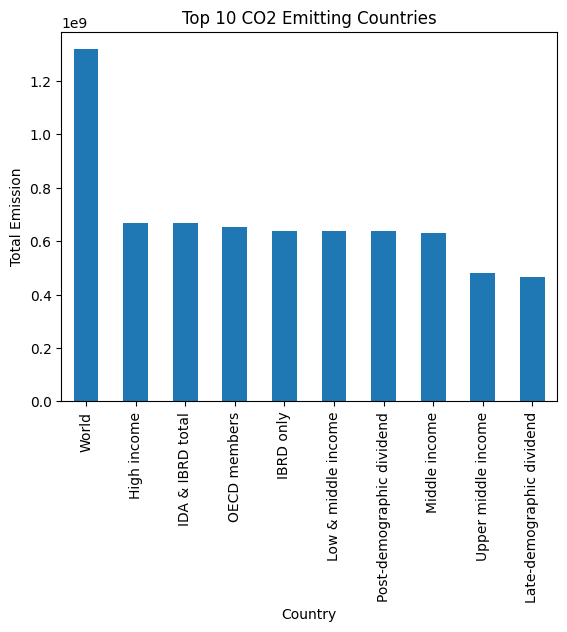

In [ ]:
top_countries = df.groupby("country_name")["value"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 CO2 Emitting Countries")
plt.xlabel("Country")
plt.ylabel("Total Emission")
plt.show()

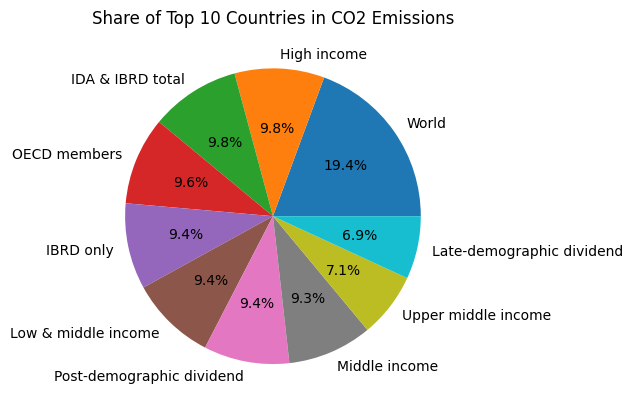

In [ ]:
plt.figure()
top_countries.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Share of Top 10 Countries in CO2 Emissions")
plt.show()


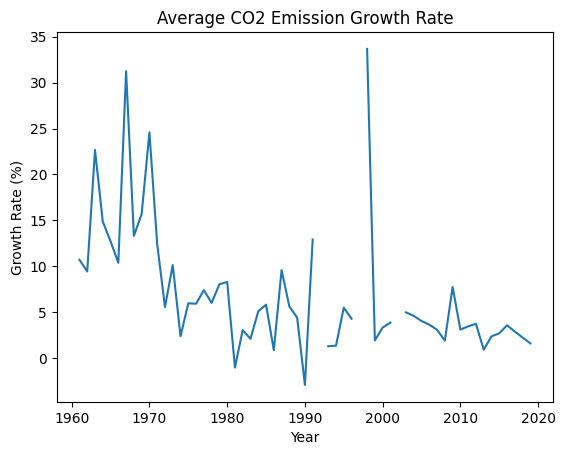

In [ ]:
df_sorted = df.sort_values(["country_name","year"])

df_sorted["growth_rate"] = df_sorted.groupby("country_name")["value"].pct_change()*100

growth = df_sorted.groupby("year")["growth_rate"].mean()

plt.figure()
plt.plot(growth.index, growth.values)
plt.title("Average CO2 Emission Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

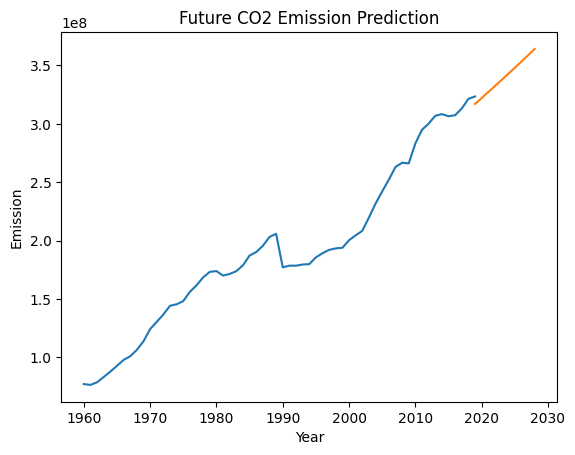

In [ ]:
# Simple future prediction using polynomial trend
years = global_trend.index.values
emissions = global_trend.values

coeff = np.polyfit(years, emissions, 2)
trend = np.poly1d(coeff)

future_years = np.arange(years.max(), years.max()+10)

future_emission = trend(future_years)

plt.figure()
plt.plot(years, emissions)
plt.plot(future_years, future_emission)
plt.title("Future CO2 Emission Prediction")
plt.xlabel("Year")
plt.ylabel("Emission")
plt.show()


In [ ]:
summary = df["value"].describe()

print("Statistical Summary of CO2 Emissions")
print(summary)


Statistical Summary of CO2 Emissions
count    1.395300e+04
mean     8.254983e+05
std      2.788923e+06
min     -8.067400e+01
25%      1.100000e+03
50%      1.390000e+04
75%      1.642779e+05
max      3.434401e+07
Name: value, dtype: float64
